### In this file I will be debugging the NN training process

There are several tests that I will go through. We will start with analyzing a NN over 1 frame.

In [1]:
'modules set up'

import os
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)
from Modules import pre_pro
import torch
from torch.utils.data import TensorDataset, DataLoader
from Modules.Neural_Net import Net
from Modules.Losses import crit
import numpy as np
from Modules.beams import beam_trim
import matplotlib.pyplot as plt

### Analysis over only one frame

- Use the same methodes as the NN training module
- Set up to train over only one frame of data
- Goal is to see if we generalize to the results we found with prior techniques

Diferences are that we are not defining a grid in the differentiation process, where in the frame by frame aproach we where

In [ ]:
'only one frame'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataloader = pre_pro.batching(input, output, workers=4)

In [23]:
'frame data set'
dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


1


In [4]:
'Network set up'
model_config = (3, 128,524,128)
net = Net(torch.cos, *model_config).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)


In [18]:
'MSE training'
save_path = 'nets/MSE/MSE_one_frame.pt'
trainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader,model_config,optimizer, net )
trainer.MSE_train(1500, prints=False, saving=True, save_path= save_path)

(0.008642720058560371, 1499)

In [ ]:
'SPT training'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
# retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-3



In [19]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(500, prints=False, saving= True, save_path='nets/SPT/spt_one_frame.pt', ly =5 )

(0.08463503420352936, 499)

### Just the component from regularization

Here I am going to alter the the method for training the NN in the prepro class. I will check the contribution of both the Regularized portion and the MSE portion of the total loss.

In [10]:
'reg and mse seperate plot'


network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-3

In [16]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

mse, reg = retrainer.SPT_debugging(500, prints=False, saving= True, save_path='nets/SPT/spt_one_frame.pt', ly =0 )

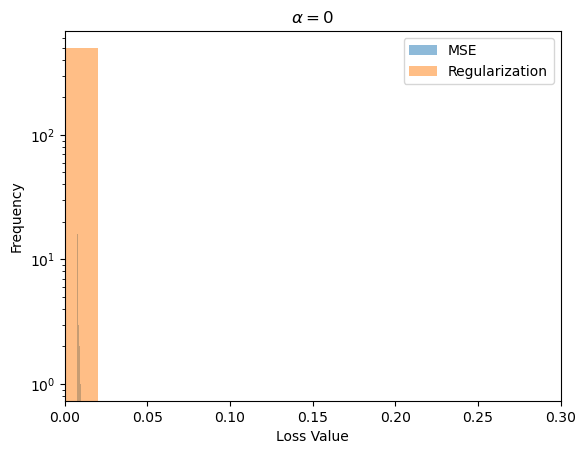

In [17]:
plt.hist(mse, bins=50, alpha=0.5, label='MSE')
plt.hist(reg, bins=50, alpha=0.5, label='Regularization')
plt.yscale('log')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.xlim(0,.3)
plt.title(r'$ \alpha = 0$')
plt.legend()
plt.show()

### Just training with regularization

In [20]:
'SPT training'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

In [21]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(1000, prints=False, saving= True, save_path='nets/SPT/spt_just_reg.pt', ly =10 )

(0.24841147661209106, 999)

### Now we will set up a frame shuffler inside of the dataloarder in the prepro class

- Makes the training more evenly dispersed
- More consistent results

In [3]:
'250 to 350 shuffled'

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


100


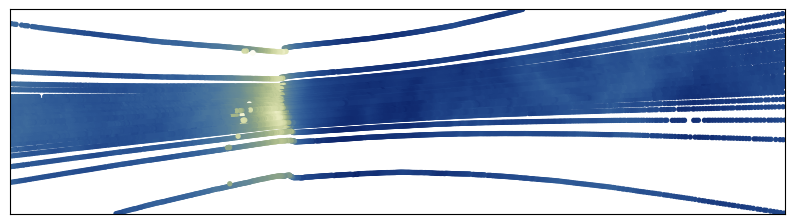

In [4]:
'checking shuffle'

import cmcrameri.cm as cmc
batch_x, batch_y = next(iter(spt_dataloader))

batch_x = batch_x.reshape(-1, 3)
batch_y = batch_y.reshape(-1, 1)


x = batch_x[:, 0].detach().numpy() 
y = batch_x[:, 1].detach().numpy()  
z = batch_y.detach().numpy().flatten()


fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(x, y, c=z, cmap=cmc.davos, vmin=0, vmax=6, s=8)
plt.xlim(-253, -132)
plt.ylim(-178, -146)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal')


plt.show()


In [ ]:
'training off shuffled data'

'Network set up'
model_config = (3, 524,1024,1024, 524, 524)
net = Net(torch.cos, *model_config).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

'MSE training'
save_path = 'nets/MSE/MSE_one_frame.pt'
trainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader,model_config,optimizer, net )
trainer.MSE_train(500, prints=True, saving=True, save_path= save_path)


In [ ]:
'Adding regularization'

network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-4

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(100, prints=True, saving= True, save_path='nets/SPT/spt_250_350.pt', ly =5 )

Epoch 0 Complete - Avg Loss: 0.238923
Epoch 1 Complete - Avg Loss: 0.140904
Epoch 2 Complete - Avg Loss: 0.143044
Epoch 3 Complete - Avg Loss: 0.152914
Epoch 4 Complete - Avg Loss: 0.163386
Epoch 5 Complete - Avg Loss: 0.159045
Epoch 6 Complete - Avg Loss: 0.153596
Epoch 7 Complete - Avg Loss: 0.167182
Epoch 8 Complete - Avg Loss: 0.167711
Epoch 9 Complete - Avg Loss: 0.176282
Epoch 10 Complete - Avg Loss: 0.170024
Epoch 11 Complete - Avg Loss: 0.176315
Epoch 12 Complete - Avg Loss: 0.183261
Epoch 13 Complete - Avg Loss: 0.179944
Epoch 14 Complete - Avg Loss: 0.180668
Epoch 15 Complete - Avg Loss: 0.184395
Epoch 16 Complete - Avg Loss: 0.186679
Epoch 17 Complete - Avg Loss: 0.191845
Epoch 18 Complete - Avg Loss: 0.188242
Epoch 19 Complete - Avg Loss: 0.195911
Epoch 20 Complete - Avg Loss: 0.190533
Epoch 21 Complete - Avg Loss: 0.187054
Epoch 22 Complete - Avg Loss: 0.195223
Epoch 23 Complete - Avg Loss: 0.198971
Epoch 24 Complete - Avg Loss: 0.200333
Epoch 25 Complete - Avg Loss: 0.197

### Making Loss curves by epoch

In [56]:
'Training Dataloader'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


1


In [57]:
'Testing Dataloader'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = [4,30]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
ver_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


1


In [ ]:
epochs, alpha = [500, 1]

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

losses = retrainer.SPT_debugging(epochs, prints=True, saving= True,
                                  save_path='nets/SPT/spt_loss_curves.pt', ly =alpha, ver_dataloader = ver_dataloader )

Epoch 0, Batch 0, Loss: 2.684027
Epoch 0 Complete - Avg Loss: 1.344869
Epoch 1, Batch 0, Loss: 1.344869
Epoch 1 Complete - Avg Loss: 1.671695
Epoch 2, Batch 0, Loss: 1.671695
Epoch 2 Complete - Avg Loss: 0.916789
Epoch 3, Batch 0, Loss: 0.916789
Epoch 3 Complete - Avg Loss: 1.006638
Epoch 4, Batch 0, Loss: 1.006638
Epoch 4 Complete - Avg Loss: 0.924409
Epoch 5, Batch 0, Loss: 0.924409
Epoch 5 Complete - Avg Loss: 0.857055
Epoch 6, Batch 0, Loss: 0.857055
Epoch 6 Complete - Avg Loss: 0.821797
Epoch 7, Batch 0, Loss: 0.821797
Epoch 7 Complete - Avg Loss: 0.983230
Epoch 8, Batch 0, Loss: 0.983230
Epoch 8 Complete - Avg Loss: 0.919039
Epoch 9, Batch 0, Loss: 0.919039
Epoch 9 Complete - Avg Loss: 0.873259
Epoch 10, Batch 0, Loss: 0.873259
Epoch 10 Complete - Avg Loss: 0.772738
Epoch 11, Batch 0, Loss: 0.772738
Epoch 11 Complete - Avg Loss: 0.739200
Epoch 12, Batch 0, Loss: 0.739200
Epoch 12 Complete - Avg Loss: 0.674363
Epoch 13, Batch 0, Loss: 0.674363
Epoch 13 Complete - Avg Loss: 0.55162

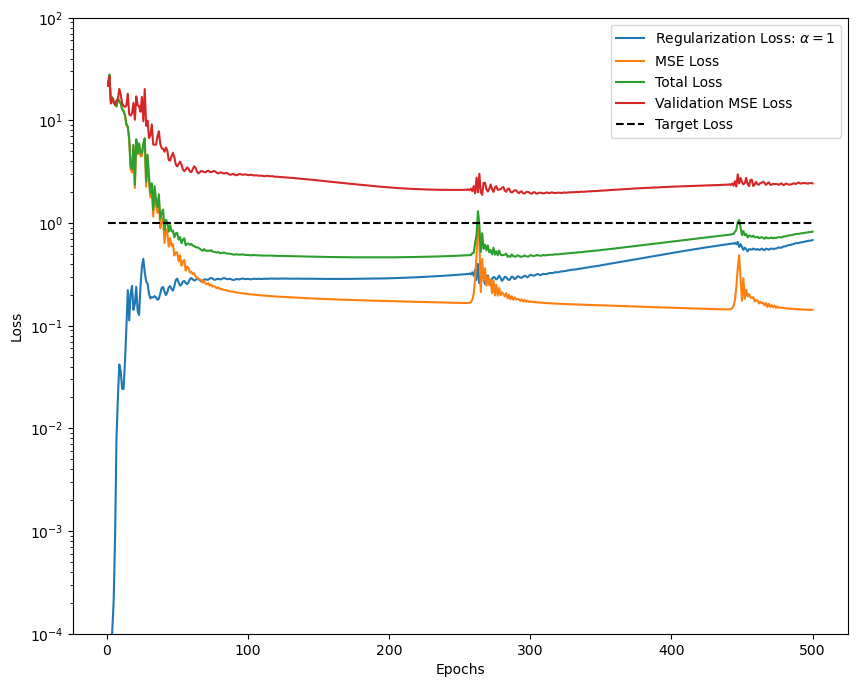

In [59]:
epoch = np.linspace(1,epochs,epochs)
fig, ax = plt.subplots(figsize=(10,8))
ax.plot(epoch, np.array(losses['reg_losses'])/.06 ,label=fr'Regularization Loss: $\alpha ={alpha}$')
ax.plot(epoch, np.array(losses['mse_losses'])/.06 ,label='MSE Loss')
ax.plot(epoch, np.array(losses['total_losses'])/.06, label='Total Loss')
ax.plot(epoch, np.array(losses['mse_ver'])/.06, label='Validation MSE Loss')
ax.plot(epoch, 1*np.ones(epochs), 'k--', label='Target Loss')
ax.set_xlabel('Epochs')
ax.set_ylim(1e-4, 100)
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
plt.show()
